This project provides a concise implementation of a Multilayer Perceptron using the Fashion-MNIST dataset. Due to the minimalist architecture, the model's accuracy is currently suboptimal, leaving significant room for further optimization.

In [27]:
import torch
from torch import nn
import torchvision
from torch.utils import data
from torchvision import transforms


In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [29]:
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="./data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="./data", train=False, transform=trans, download=True)

In [30]:
def get_fashion_mnist_labels(labels):  
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

In [31]:
batch_size=256

def get_dataloader_workers():  
    return 4

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True,
                             num_workers=get_dataloader_workers())

In [32]:
def load_data_fashion_mnist(batch_size, resize=None):  
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="./data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="./data", train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=get_dataloader_workers()))

In [33]:
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 256),
                    nn.ReLU(),
                    nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)
net.to(device)


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=10, bias=True)
)

In [34]:
lr, epochs =  0.1, 10
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train_iter, test_iter = load_data_fashion_mnist(batch_size)



In [35]:
def evaluate_accuracy(net, data_iter):
    if isinstance(net, torch.nn.Module):
        net.eval()  # 设置为评估模式
    
    metric = [0.0, 0.0]  # 正确预测数, 预测总数
    
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            metric[0] += float((y_hat.argmax(dim=1) == y).sum())
            metric[1] += float(y.numel())
    
    return metric[0] / metric[1]

In [36]:
def train_epoch(net, train_iter, loss, trainer):
    # 设置为训练模式
    if isinstance(net, torch.nn.Module):
        net.train()
    
    total_loss, total_acc, total_samples = 0, 0, 0
    
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        trainer.zero_grad()  
        l.mean().backward()  
        trainer.step()       
    
        total_loss += float(l.sum())
        total_acc += float((y_hat.argmax(dim=1) == y).sum())
        total_samples += y.numel()
        
    return total_loss / total_samples, total_acc / total_samples

        


In [37]:
def train(net, train_iter, test_iter, loss, num_epochs, trainer):
    for epoch in range(num_epochs):
        train_metrics = train_epoch(net, train_iter, loss, trainer)
        test_acc = evaluate_accuracy(net, test_iter)
        
        print(f'epoch {epoch + 1}: loss {train_metrics[0]:.4f}, '
              f'train acc {train_metrics[1]:.4f}, test acc {test_acc:.4f}')

In [38]:
num_epochs = 10
train(net, train_iter, test_iter, loss, num_epochs, trainer)

epoch 1: loss 1.0473, train acc 0.6335, test acc 0.7489
epoch 2: loss 0.5991, train acc 0.7883, test acc 0.8085
epoch 3: loss 0.5190, train acc 0.8194, test acc 0.7998
epoch 4: loss 0.4808, train acc 0.8316, test acc 0.8256
epoch 5: loss 0.4538, train acc 0.8406, test acc 0.8160
epoch 6: loss 0.4311, train acc 0.8483, test acc 0.8182
epoch 7: loss 0.4167, train acc 0.8533, test acc 0.8414
epoch 8: loss 0.4037, train acc 0.8576, test acc 0.8201
epoch 9: loss 0.3919, train acc 0.8603, test acc 0.8459
epoch 10: loss 0.3828, train acc 0.8645, test acc 0.8419


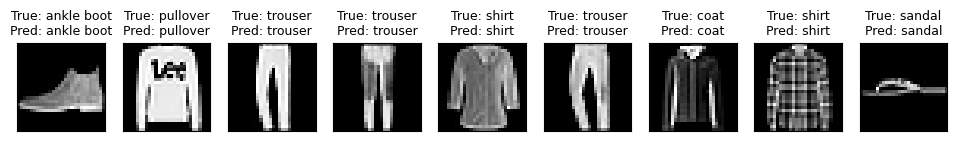

In [39]:
import matplotlib.pyplot as plt
def predict_demo(net, test_iter, n=9):
    for X, y in test_iter:
        X = X.to(device) 
        y = y.to(device)
        break
    trues = get_fashion_mnist_labels(y)
    preds = get_fashion_mnist_labels(net(X).argmax(dim=1))
    titles = [f'True: {t}\nPred: {p}' for t, p in zip(trues, preds)]
    

    plt.figure(figsize=(12, 3))

    for i in range(n):
        ax = plt.subplot(1, n, i + 1)
        plt.imshow(X[i].cpu().reshape(28, 28).numpy(), cmap='gray') # 将 Tensor 转回 (28, 28) 的形状，并传回cpu
        plt.title(titles[i], fontsize=9)

        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        
    plt.show()
predict_demo(net, test_iter)